# Filtro Bayer

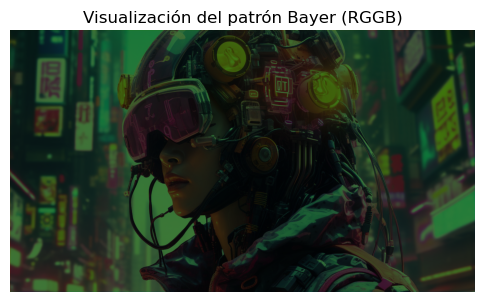

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("colores2.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

# imagen para visualizar el mosaico
bayer_visual = np.zeros_like(img)

for i in range(h):
    for j in range(w):

        if i % 2 == 0 and j % 2 == 0:   # R
            bayer_visual[i,j] = [R[i,j],0,0]

        elif i % 2 == 0 and j % 2 == 1: # G
            bayer_visual[i,j] = [0,G[i,j],0]

        elif i % 2 == 1 and j % 2 == 0: # G
            bayer_visual[i,j] = [0,G[i,j],0]

        else:                           # B
            bayer_visual[i,j] = [0,0,B[i,j]]

plt.figure(figsize=(6,6))
plt.imshow(bayer_visual)
plt.title("Visualización del patrón Bayer (RGGB)")
plt.axis("off")
plt.show()

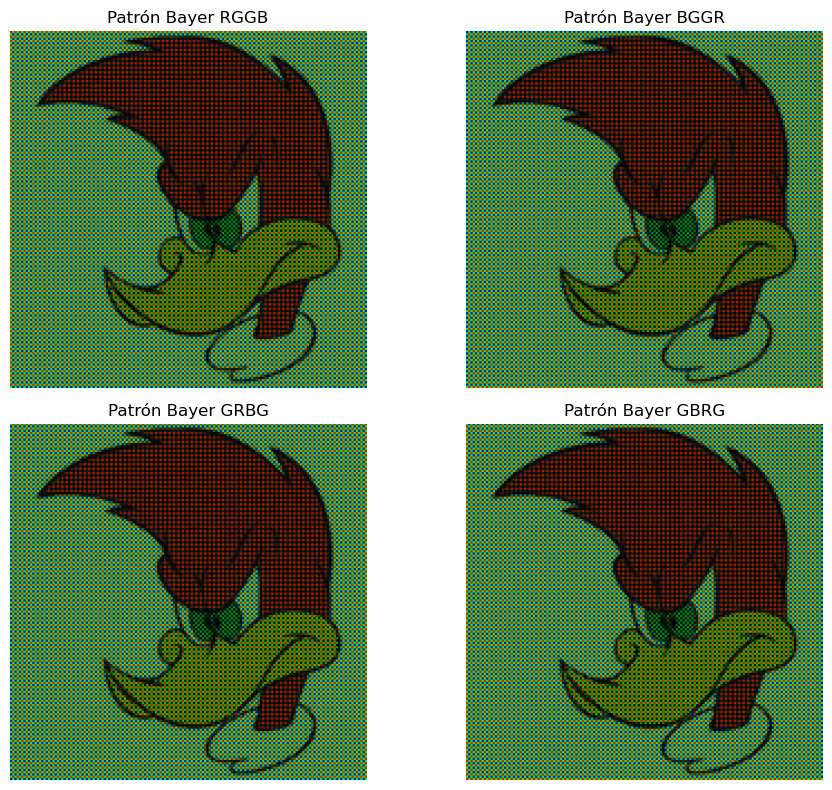

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen
img = cv2.imread("loco-2.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Reducimos la imagen para que el patrón sea visible
img = cv2.resize(img,(160,160))

h,w,_ = img.shape

def aplicar_bayer(img,patron):

    resultado = np.zeros_like(img)

    if patron=="RGGB":

        resultado[0::2,0::2,0] = img[0::2,0::2,0]  # R
        resultado[0::2,1::2,1] = img[0::2,1::2,1]  # G
        resultado[1::2,0::2,1] = img[1::2,0::2,1]  # G
        resultado[1::2,1::2,2] = img[1::2,1::2,2]  # B

    if patron=="BGGR":

        resultado[0::2,0::2,2] = img[0::2,0::2,2]  # B
        resultado[0::2,1::2,1] = img[0::2,1::2,1]  # G
        resultado[1::2,0::2,1] = img[1::2,0::2,1]  # G
        resultado[1::2,1::2,0] = img[1::2,1::2,0]  # R

    if patron=="GRBG":

        resultado[0::2,0::2,1] = img[0::2,0::2,1]  # G
        resultado[0::2,1::2,0] = img[0::2,1::2,0]  # R
        resultado[1::2,0::2,2] = img[1::2,0::2,2]  # B
        resultado[1::2,1::2,1] = img[1::2,1::2,1]  # G

    if patron=="GBRG":

        resultado[0::2,0::2,1] = img[0::2,0::2,1]  # G
        resultado[0::2,1::2,2] = img[0::2,1::2,2]  # B
        resultado[1::2,0::2,0] = img[1::2,0::2,0]  # R
        resultado[1::2,1::2,1] = img[1::2,1::2,1]  # G

    return resultado


patrones = ["RGGB","BGGR","GRBG","GBRG"]

plt.figure(figsize=(10,8))

for i,p in enumerate(patrones):

    img_bayer = aplicar_bayer(img,p)

    # agrandar pixeles pero no tanto
    img_bayer = cv2.resize(img_bayer,None,fx=3,fy=3,interpolation=cv2.INTER_NEAREST)

    plt.subplot(2,2,i+1)
    plt.imshow(img_bayer)
    plt.title("Patrón Bayer "+p)
    plt.axis("off")

plt.tight_layout()
plt.show()

# RGB a YUV

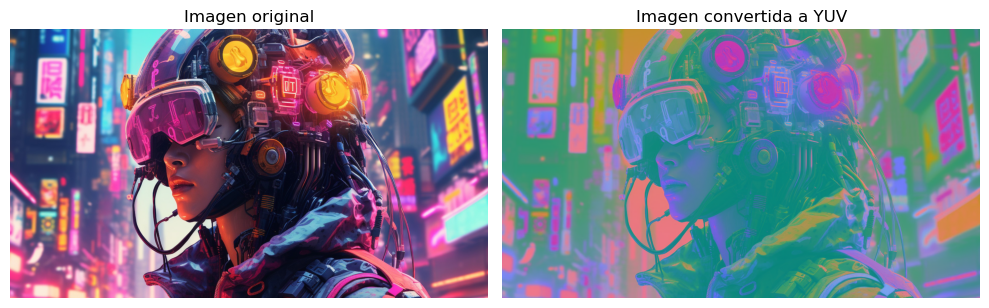

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("colores2.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convertir de BGR a YUV
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

# Guardar imagen YUV
# cv2.imwrite("imagen_yuv.jpg", img_yuv)

# Mostrar imágenes
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_yuv)
plt.title("Imagen convertida a YUV")
plt.axis("off")

plt.tight_layout()
plt.show()

# YUV a RGB

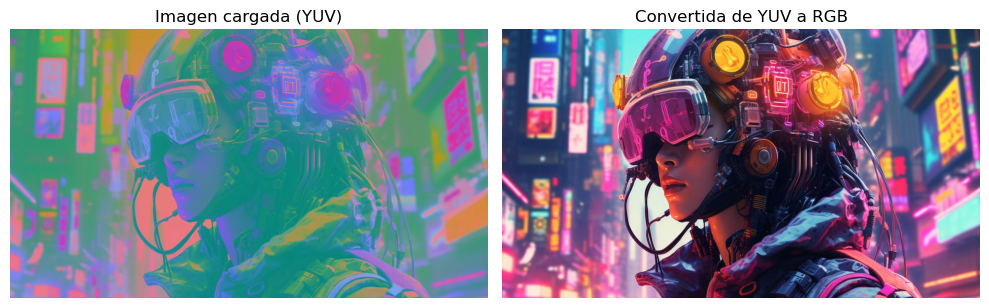

In [8]:
import cv2
import matplotlib.pyplot as plt

# Cargar imagen guardada en YUV
img_yuv = cv2.imread("imagen_yuv.jpg")

# Convertir de YUV a RGB
img_rgb = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_yuv)
plt.title("Imagen cargada (YUV)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_rgb)
plt.title("Convertida de YUV a RGB")
plt.axis("off")

plt.tight_layout()
plt.show()